# CSC221 Group Project

## MLB Standings Data Collection Using the MLB Stats API

**Name:** Brendan Scholtes

**Partner:** Janay Snell

## Project Description

This project collects Major League Baseball standings data using the MLB Stats API. The data includes team names, wins, losses, and winning percentages. The information is organized into a Pandas DataFrame, displayed in the notebook, and saved as a CSV file named **CSC221-GP-data.csv**.

## Step 1: Import Libraries

Import the libraries needed to request data from the API and organize the results into a DataFrame.

In [1]:
import requests
import pandas as pd

## Step 2: Retrieve Data from the API

This section sends a request to the MLB Stats API to collect current MLB standings information.

In [2]:
url = "https://statsapi.mlb.com/api/v1/standings?leagueId=103,104&season=2025&standingsTypes=regularSeason"

response = requests.get(url)

data = response.json()

## Step 3: Create the DataFrame

This section extracts team standings information from the API response and stores it in a Pandas DataFrame.

In [3]:
standings = []

for record in data["records"]:
    for team in record["teamRecords"]:
        standings.append({
            "Team": team["team"]["name"],
            "Wins": team["wins"],
            "Losses": team["losses"],
            "Win Percentage": team["winningPercentage"],
            "Games Played": team["gamesPlayed"]
        })

df = pd.DataFrame(standings)

## Step 4: Display the Data

The first 10 rows of the DataFrame are displayed so the collected MLB standings data can be reviewed directly inside the notebook.

In [4]:
df.head(10)

,Team,Wins,Losses,Win Percentage,Games Played
0,Blue Jays,94,68,.580,162
1,Yankees,94,68,.580,162
2,Red Sox,89,73,.549,162
3,Rays,77,85,.475,162
4,Orioles,75,87,.463,162
5,Guardians,88,74,.543,162
6,Tigers,87,75,.537,162
7,Royals,82,80,.506,162
8,Twins,70,92,.432,162
9,White Sox,60,102,.370,162


## Step 5: Save Data to CSV

This section saves the completed DataFrame as a CSV file named **CSC221-GP-data.csv**.

In [5]:
df.to_csv("CSC221-GP-data.csv", index=False)

print("CSC221-GP-data.csv has been saved successfully!")

CSC221-GP-data.csv has been saved successfully!


## Graph 1: MLB Team Wins

I chose a bar chart because it makes it easy to compare the number of wins for each MLB team. Sorting the teams from highest to lowest wins helps show which teams had the best and worst records. The labels and gridlines also make the graph easier to read.

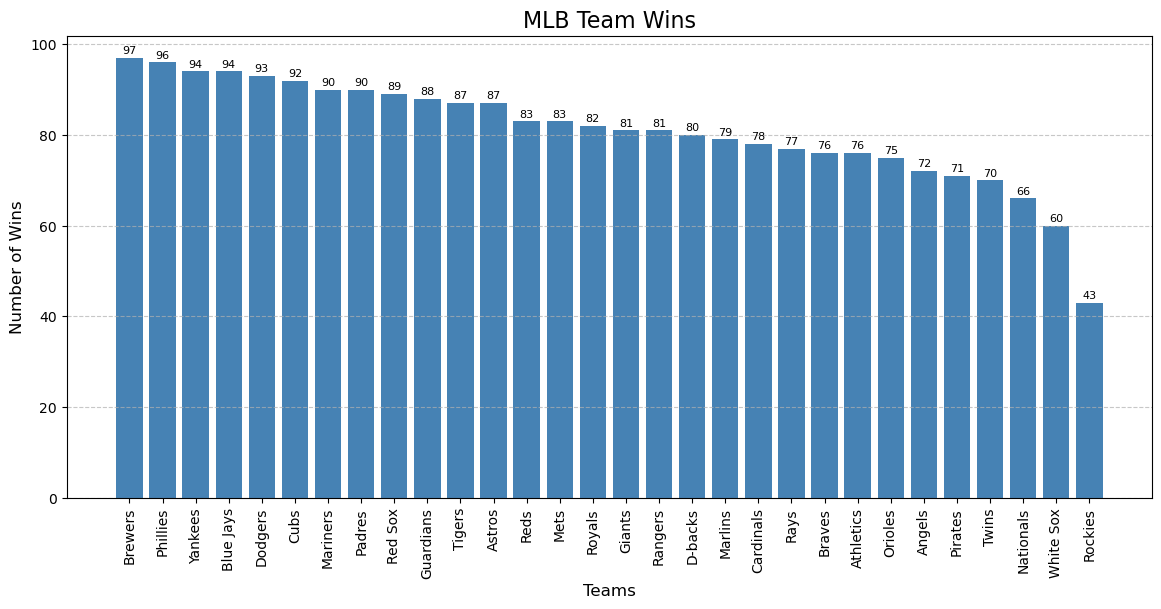

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

#load data
df = pd.read_csv("CSC221-GP-data.csv")

#sort teams by wins (highest to lowest)
df_sorted = df.sort_values(by="Wins", ascending=False)

#create the figure
plt.figure(figsize=(14,6))

#create the bar chart
bars = plt.bar(df_sorted["Team"], df_sorted["Wins"], color="steelblue")

#add titles and labels
plt.title("MLB Team Wins", fontsize=16)
plt.xlabel("Teams", fontsize=12)
plt.ylabel("Number of Wins", fontsize=12)

#readability
plt.xticks(rotation=90)

#add gridlines horizontally
plt.grid(axis='y', linestyle='--', alpha=0.7)

#value labels
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        int(bar.get_height()),
        ha='center',
        va='bottom',
        fontsize=8
    )

#display the graph
plt.show()

## Graph 2: Wins vs. Winning Percentage

I chose a scatter plot because it is a good way to compare two sets of numbers. Each point on the graph represents one MLB team. This graph shows that teams with more wins usually have a higher winning percentage, making the relationship between the two easy to see.

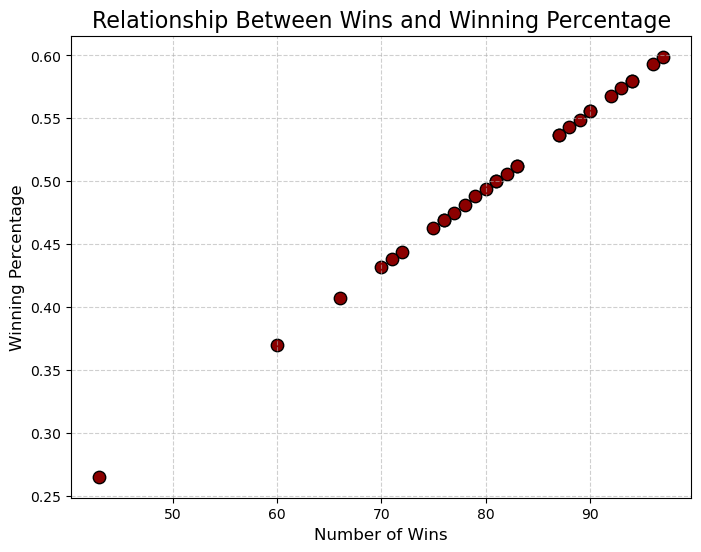

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

#load data
df = pd.read_csv("CSC221-GP-data.csv")

#create scatter plot
plt.figure(figsize=(8,6))

plt.scatter(
    df["Wins"],
    df["Win Percentage"],
    color="darkred",
    edgecolors="black",
    s=80
)

#add titles and labels
plt.title("Relationship Between Wins and Winning Percentage", fontsize=16)
plt.xlabel("Number of Wins", fontsize=12)
plt.ylabel("Winning Percentage", fontsize=12)

#add gridlines
plt.grid(True, linestyle="--", alpha=0.6)

#display the graph
plt.show()